<a href="https://colab.research.google.com/github/LiLAlien28/Arch_Tech_internship/blob/main/Task4_Iris_Flower_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IRIS FLOWER CLASSIFICATION TASK

📊 1. LOADING AND EXPLORING DATASET
----------------------------------------
Dataset shape: (150, 5)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column 

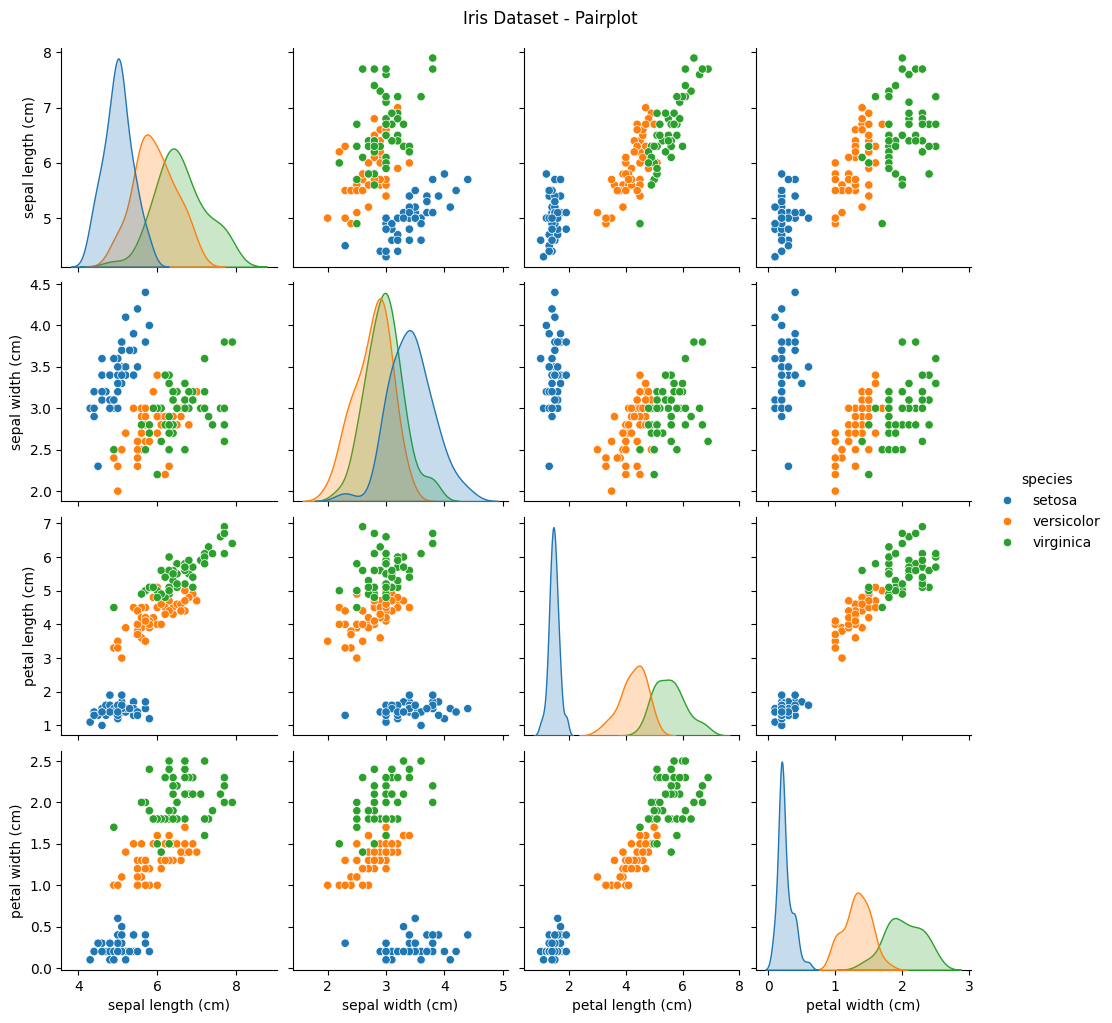

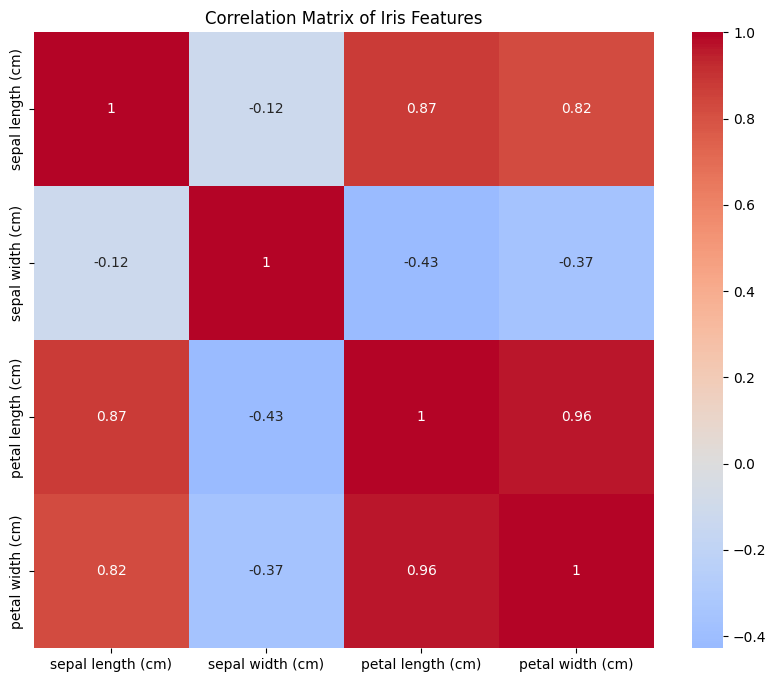

Correlation with features:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


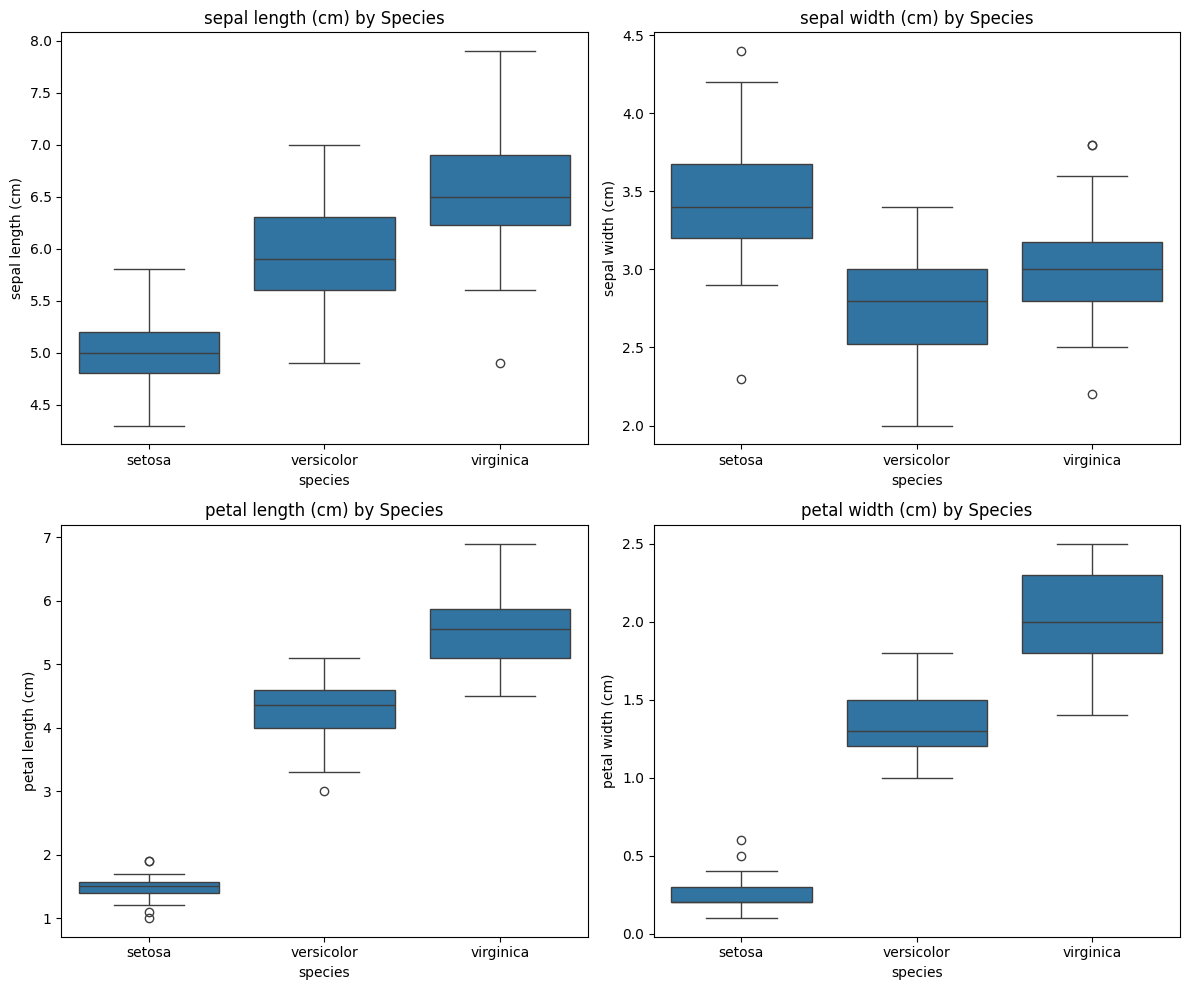


🔄 3. DATA PREPARATION
----------------------------------------
Training set size: (120, 4)
Testing set size: (30, 4)

Training set species distribution:
species
setosa        40
versicolor    40
virginica     40
Name: count, dtype: int64

Testing set species distribution:
species
setosa        10
versicolor    10
virginica     10
Name: count, dtype: int64

Features have been standardized (mean=0, std=1)

🤖 4. TRAINING MULTIPLE CLASSIFIERS
----------------------------------------

Training Logistic Regression...
  Train Accuracy: 0.9583
  Test Accuracy: 0.9333
  CV Accuracy: 0.9583 (+/- 0.0527)

Training K-Nearest Neighbors...
  Best Parameters: {'n_neighbors': 5}
  Train Accuracy: 0.9750
  Test Accuracy: 0.9333
  CV Accuracy: 0.9667 (+/- 0.0624)

Training Support Vector Machine...
  Best Parameters: {'C': 1, 'gamma': 0.1}
  Train Accuracy: 0.9833
  Test Accuracy: 0.9667
  CV Accuracy: 0.9833 (+/- 0.0667)

Training Decision Tree...
  Train Accuracy: 1.0000
  Test Accuracy: 0.9333
  CV 

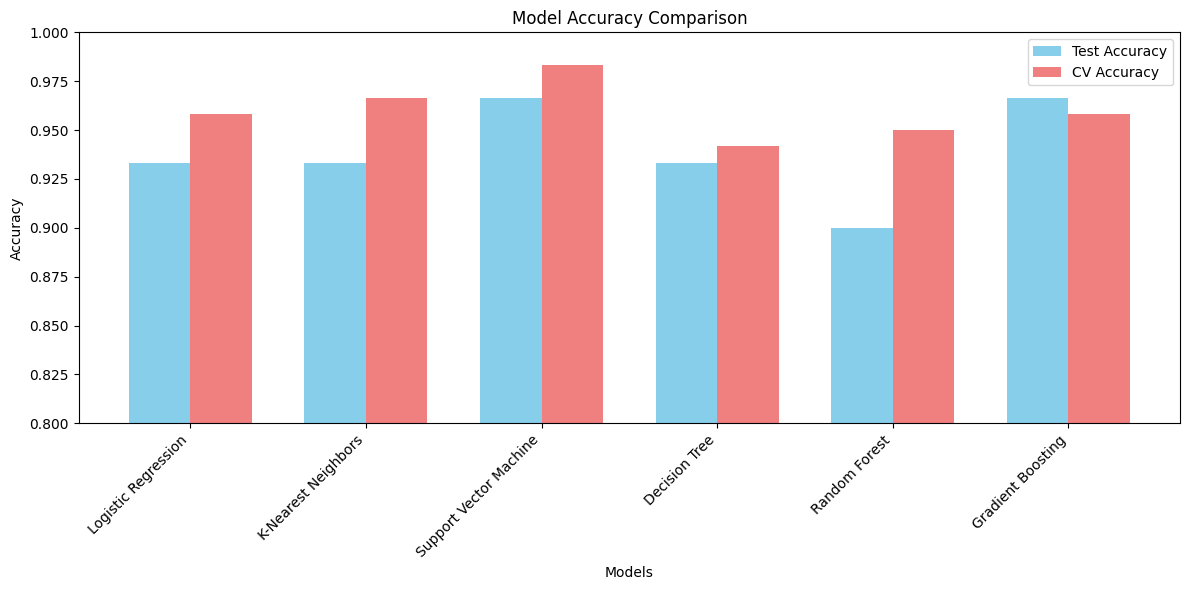


🏆 6. BEST MODEL ANALYSIS
----------------------------------------
Best Model: Support Vector Machine
Best Test Accuracy: 0.9667
Best CV Accuracy: 0.9833


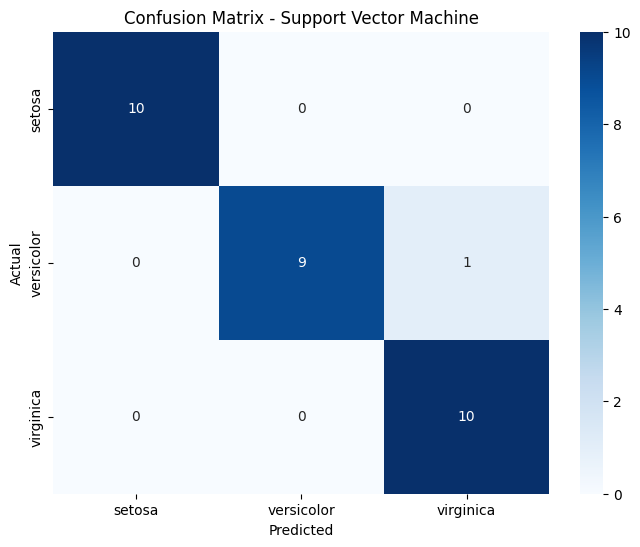


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


🔍 7. FEATURE IMPORTANCE ANALYSIS
----------------------------------------
Feature importance not available for Support Vector Machine

🎯 8. DECISION BOUNDARY VISUALIZATION
----------------------------------------


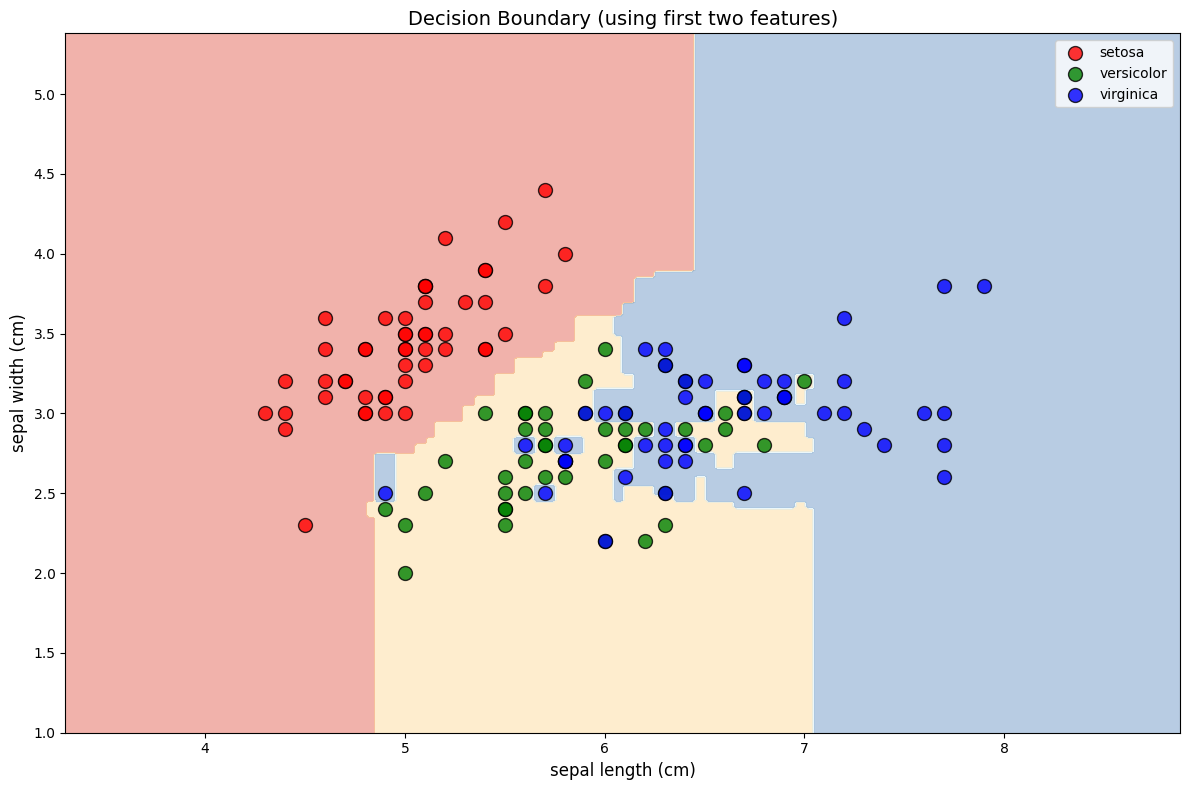

✅ Decision boundary visualization complete!

🔮 9. SAMPLE PREDICTIONS
----------------------------------------

Sample Predictions on Test Set:
  Actual: setosa       | Predicted: setosa       | Confidence: 96.76%
  Actual: versicolor   | Predicted: versicolor   | Confidence: 95.12%
  Actual: virginica    | Predicted: virginica    | Confidence: 98.95%
  Actual: setosa       | Predicted: setosa       | Confidence: 97.46%
  Actual: virginica    | Predicted: virginica    | Confidence: 97.86%

🎯 10. PREDICTION FUNCTION FOR NEW SAMPLES
----------------------------------------

Testing Prediction Function with Sample Measurements:
----------------------------------------
Sample 1: [5.1, 3.5, 1.4, 0.2]
  → Predicted: setosa (Confidence: 97.70%)
Sample 2: [6.5, 3.0, 5.2, 2.0]
  → Predicted: virginica (Confidence: 94.21%)
Sample 3: [5.9, 3.0, 4.2, 1.5]
  → Predicted: versicolor (Confidence: 95.59%)
Sample 4: [4.9, 3.0, 1.4, 0.2]
  → Predicted: setosa (Confidence: 95.62%)
Sample 5: [6.3, 3.3, 6.0

In [4]:
# Task 4: Iris Flower Classification
# Machine Learning Internship - Month 2
# ARCH TECHNOLOGIES

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')
import joblib

print("="*60)
print("IRIS FLOWER CLASSIFICATION TASK")
print("="*60)

# ==================== 1. LOAD AND EXPLORE DATASET ====================
print("\n📊 1. LOADING AND EXPLORING DATASET")
print("-"*40)

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Dataset shape: {df.shape}")
print(f"Features: {list(iris.feature_names)}")
print(f"Target classes: {list(iris.target_names)}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nStatistical summary:")
print(df.describe())
print("\nSpecies distribution:")
print(df['species'].value_counts())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# ==================== 2. EXPLORATORY DATA ANALYSIS ====================
print("\n📈 2. EXPLORATORY DATA ANALYSIS")
print("-"*40)

# Pairplot
print("Creating pairplot...")
g = sns.pairplot(df, hue='species', height=2.5)
plt.suptitle('Iris Dataset - Pairplot', y=1.02)
plt.savefig('iris_pairplot.png')
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df.iloc[:, :-1].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            xticklabels=iris.feature_names, yticklabels=iris.feature_names)
plt.title('Correlation Matrix of Iris Features')
plt.savefig('iris_correlation.png')
plt.show()

print("Correlation with features:")
print(correlation_matrix)

# Box plots for each feature by species
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, feature in enumerate(iris.feature_names):
    sns.boxplot(x='species', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'{feature} by Species')

plt.tight_layout()
plt.savefig('iris_boxplots.png')
plt.show()

# ==================== 3. DATA PREPARATION ====================
print("\n🔄 3. DATA PREPARATION")
print("-"*40)

# Prepare features and target
X = df[iris.feature_names]
y = df['species']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nTraining set species distribution:")
print(y_train.value_counts())
print(f"\nTesting set species distribution:")
print(y_test.value_counts())

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures have been standardized (mean=0, std=1)")

# ==================== 4. TRAIN MULTIPLE MODELS ====================
print("\n🤖 4. TRAINING MULTIPLE CLASSIFIERS")
print("-"*40)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42, probability=True),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Hyperparameter tuning grids
param_grids = {
    'K-Nearest Neighbors': {'n_neighbors': [3, 5, 7, 9, 11]},
    'Support Vector Machine': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.1, 0.01]},
    'Random Forest': {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
}

# Train and evaluate models
results = {}
best_estimators = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name in param_grids:
        # Use GridSearchCV for hyperparameter tuning
        grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy')
        grid_search.fit(X_train_scaled, y_train)
        best_model = grid_search.best_estimator_
        best_estimators[name] = best_model
        print(f"  Best Parameters: {grid_search.best_params_}")
    else:
        best_model = model
        best_model.fit(X_train_scaled, y_train)
        best_estimators[name] = best_model

    # Make predictions
    y_pred_train = best_model.predict(X_train_scaled)
    y_pred_test = best_model.predict(X_test_scaled)

    # Calculate accuracy
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)

    # Cross-validation
    cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'CV Accuracy Mean': cv_scores.mean(),
        'CV Accuracy Std': cv_scores.std()
    }

    print(f"  Train Accuracy: {train_accuracy:.4f}")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# ==================== 5. MODEL COMPARISON ====================
print("\n📊 5. MODEL PERFORMANCE COMPARISON")
print("-"*40)

# Create comparison dataframe
comparison_df = pd.DataFrame(results).T
print("\nModel Performance Summary:")
print(comparison_df.round(4))

# Plot comparison
plt.figure(figsize=(12, 6))
models_list = list(results.keys())
test_accuracies = [results[m]['Test Accuracy'] for m in models_list]
cv_means = [results[m]['CV Accuracy Mean'] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.bar(x - width/2, test_accuracies, width, label='Test Accuracy', color='skyblue')
plt.bar(x + width/2, cv_means, width, label='CV Accuracy', color='lightcoral')

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(x, models_list, rotation=45, ha='right')
plt.legend()
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.savefig('iris_model_comparison.png')
plt.show()

# ==================== 6. BEST MODEL ANALYSIS ====================
print("\n🏆 6. BEST MODEL ANALYSIS")
print("-"*40)

# Find the best model
best_model_name = max(results, key=lambda x: results[x]['Test Accuracy'])
best_model = best_estimators[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Best Test Accuracy: {results[best_model_name]['Test Accuracy']:.4f}")
print(f"Best CV Accuracy: {results[best_model_name]['CV Accuracy Mean']:.4f}")

# Confusion Matrix for best model
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.savefig('iris_confusion_matrix.png')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=iris.target_names))

# ==================== 7. FEATURE IMPORTANCE ====================
print("\n🔍 7. FEATURE IMPORTANCE ANALYSIS")
print("-"*40)

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': iris.feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.bar(feature_importance['Feature'], feature_importance['Importance'], color='green')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('iris_feature_importance.png')
    plt.show()

    print("\nFeature Importance:")
    print(feature_importance)
elif hasattr(best_model, 'coef_'):
    # For linear models, use coefficients
    coef_importance = np.abs(best_model.coef_).mean(axis=0)
    feature_importance = pd.DataFrame({
        'Feature': iris.feature_names,
        'Importance': coef_importance
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.bar(feature_importance['Feature'], feature_importance['Importance'], color='green')
    plt.xlabel('Features')
    plt.ylabel('|Coefficient|')
    plt.title(f'Feature Importance (Coefficient Magnitude) - {best_model_name}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('iris_feature_importance.png')
    plt.show()

    print("\nFeature Importance (based on coefficient magnitude):")
    print(feature_importance)
else:
    print(f"Feature importance not available for {best_model_name}")

# ==================== 8. DECISION BOUNDARY VISUALIZATION ====================
print("\n🎯 8. DECISION BOUNDARY VISUALIZATION")
print("-"*40)

# Convert species to numeric values for contour plot
le = LabelEncoder()
y_numeric = le.fit_transform(y)

# Create a mesh for decision boundary
x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Use only first two features for visualization
X_vis = X.iloc[:, :2]
scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

# Train a simple model on first two features
simple_model = RandomForestClassifier(n_estimators=50, random_state=42)
simple_model.fit(X_vis_scaled, y_numeric)

# Predict on mesh grid
Z = simple_model.predict(scaler_vis.transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(12, 8))

# Use contourf with numeric Z values
contour = plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu', levels=3)

# Plot training points
colors = ['red', 'green', 'blue']
for i, species in enumerate(['setosa', 'versicolor', 'virginica']):
    species_data = X_vis[y == species]
    plt.scatter(species_data.iloc[:, 0], species_data.iloc[:, 1],
               label=species, c=colors[i], edgecolor='black', s=100, alpha=0.8)

plt.xlabel(iris.feature_names[0], fontsize=12)
plt.ylabel(iris.feature_names[1], fontsize=12)
plt.title('Decision Boundary (using first two features)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('iris_decision_boundary.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Decision boundary visualization complete!")

# ==================== 9. SAMPLE PREDICTIONS ====================
print("\n🔮 9. SAMPLE PREDICTIONS")
print("-"*40)

print("\nSample Predictions on Test Set:")
sample_indices = np.random.choice(len(X_test), 5, replace=False)
for idx in sample_indices:
    actual = y_test.iloc[idx]
    predicted = y_pred_best[idx]

    if hasattr(best_model, 'predict_proba'):
        proba = best_model.predict_proba(X_test_scaled[idx].reshape(1, -1))[0]
        confidence = np.max(proba)
        print(f"  Actual: {actual:12} | Predicted: {predicted:12} | Confidence: {confidence:.2%}")
    else:
        print(f"  Actual: {actual:12} | Predicted: {predicted:12}")

# ==================== 10. PREDICTION FUNCTION ====================
print("\n🎯 10. PREDICTION FUNCTION FOR NEW SAMPLES")
print("-"*40)

def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    """
    Predict iris species for new measurements

    Parameters:
    sepal_length, sepal_width, petal_length, petal_width: float
        Flower measurements in cm

    Returns:
    tuple: (predicted_species, confidence_score)
    """
    new_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    new_data_scaled = scaler.transform(new_data)
    prediction = best_model.predict(new_data_scaled)[0]

    if hasattr(best_model, 'predict_proba'):
        probabilities = best_model.predict_proba(new_data_scaled)[0]
        confidence = max(probabilities)
        return prediction, confidence
    else:
        return prediction, None

# Test the prediction function
print("\nTesting Prediction Function with Sample Measurements:")
print("-"*40)

test_samples = [
    [5.1, 3.5, 1.4, 0.2],  # Setosa characteristics
    [6.5, 3.0, 5.2, 2.0],  # Virginica characteristics
    [5.9, 3.0, 4.2, 1.5],  # Versicolor characteristics
    [4.9, 3.0, 1.4, 0.2],  # Another Setosa
    [6.3, 3.3, 6.0, 2.5],  # Another Virginica
]

for i, sample in enumerate(test_samples, 1):
    species, confidence = predict_iris(*sample)
    if confidence:
        print(f"Sample {i}: {sample}")
        print(f"  → Predicted: {species} (Confidence: {confidence:.2%})")
    else:
        print(f"Sample {i}: {sample} -> Predicted: {species}")

# ==================== 11. SAVE MODELS ====================
print("\n💾 11. SAVING MODELS")
print("-"*40)

# Save the best model and scaler
joblib.dump(best_model, 'iris_classifier_model.pkl')
joblib.dump(scaler, 'iris_scaler.pkl')

print("✅ Model saved as 'iris_classifier_model.pkl'")
print("✅ Scaler saved as 'iris_scaler.pkl'")

# Save all models for comparison
all_models = {}
for name, model in best_estimators.items():
    all_models[name] = model
joblib.dump(all_models, 'all_iris_models.pkl')
print("✅ All models saved as 'all_iris_models.pkl'")

# ==================== 12. SUMMARY REPORT ====================
print("\n📋 12. TASK SUMMARY REPORT")
print("="*60)
print(f"""
IRIS FLOWER CLASSIFICATION - TASK COMPLETED
============================================

Dataset Information:
- Total Samples: {len(df)}
- Features: 4 (sepal length, sepal width, petal length, petal width)
- Target Classes: 3 (setosa, versicolor, virginica)

Best Model: {best_model_name}
Best Test Accuracy: {results[best_model_name]['Test Accuracy']:.2%}
Cross-validation Accuracy: {results[best_model_name]['CV Accuracy Mean']:.2%} (+/- {results[best_model_name]['CV Accuracy Std']*2:.2%})

Model Performance Summary:
""")

for name in models_list:
    print(f"{name:25} Test Acc: {results[name]['Test Accuracy']:.2%} | CV Acc: {results[name]['CV Accuracy Mean']:.2%}")

print("""
============================================
✅ Task 4: Iris Flower Classification Completed Successfully!
📊 Visualizations saved as PNG files
💾 Models saved as PKL files
============================================
""")


